In [1]:
import baostock as bs
import pandas as pd

lg = bs.login()

rs = bs.query_history_k_data_plus(
    "sz.000001",
    "date,open,high,low,close,volume",
    start_date="2024-04-01",
    end_date="2025-04-01",
    frequency="d",
    adjustflag="2"        # 前复权
)

data_list = []
while (rs.error_code == '0') and rs.next():
    data_list.append(rs.get_row_data())

df = pd.DataFrame(data_list, columns=rs.fields)

bs.logout()

# Clean
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = pd.to_numeric(df[col])
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

login success!
logout success!


In [3]:
print(df.shape)     
df.dtypes


(242, 5)


open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [4]:
df.loc['2024-09-24']

open      9.394050e+00
high      9.635638e+00
low       9.366175e+00
close     9.635638e+00
volume    1.638213e+08
Name: 2024-09-24 00:00:00, dtype: float64

In [5]:
df.iloc[0]

open      9.123344e+00
high      9.236085e+00
low       9.114671e+00
close     9.227412e+00
volume    1.191088e+08
Name: 2024-04-01 00:00:00, dtype: float64

In [7]:
df.iloc[-1]

open      1.070094e+01
high      1.072943e+01
low       1.065347e+01
close     1.070094e+01
volume    6.814704e+07
Name: 2025-04-01 00:00:00, dtype: float64

In [8]:
print("iloc gives", len(df.iloc[0:3]), "rows")
print(df.iloc[0:3])
print()
print("loc gives", len(df.loc['2024-04-01':'2024-04-03']), "rows")
print(df.loc['2024-04-01':'2024-04-03'])

iloc gives 3 rows
                open      high       low     close     volume
date                                                         
2024-04-01  9.123344  9.236085  9.114671  9.227412  119108796
2024-04-02  9.218740  9.262102  9.132016  9.149361  108545826
2024-04-03  9.132016  9.149361  9.036620  9.071309   98184585

loc gives 3 rows
                open      high       low     close     volume
date                                                         
2024-04-01  9.123344  9.236085  9.114671  9.227412  119108796
2024-04-02  9.218740  9.262102  9.132016  9.149361  108545826
2024-04-03  9.132016  9.149361  9.036620  9.071309   98184585


In [ ]:
# Nuance: iloc is insensitive to holidays and counts tradings days, while loc is sensitive to trading days
print("iloc[0:5] gives", len(df.iloc[0:5]), "rows")
print("loc April 1-5 gives", len(df.loc['2024-04-01':'2024-04-05']), "rows")

iloc[0:5] gives 5 rows
loc April 1-5 gives 3 rows


In [10]:
df['close'] > df['open']

date
2024-04-01     True
2024-04-02    False
2024-04-03    False
2024-04-08     True
2024-04-09    False
              ...  
2025-03-26    False
2025-03-27     True
2025-03-28    False
2025-03-31    False
2025-04-01    False
Length: 242, dtype: bool

In [11]:
up_days = df[df['close'] > df['open']]
print(len(up_days), "up days out of", len(df), "total")

119 up days out of 242 total


In [12]:
# Days where close > open AND volume > 100 million
big_up = df[(df['close'] > df['open']) & (df['volume'] > 100_000_000)]
print(len(big_up), "big up days")

73 big up days


In [13]:
# Days where close hit the daily high OR volume was below 50 million
extreme = df[(df['close'] == df['high']) | (df['volume'] < 50_000_000)]
print(len(extreme), "days matching either condition")

14 days matching either condition


In [14]:
# All trading days in September 2024 (the PBOC stimulus rally month)
september = df[df.index.month == 9]
print(len(september), "trading days in September 2024")
print(september.tail())

19 trading days in September 2024
                 open       high        low      close     volume
date                                                             
2024-09-24   9.394050   9.635638   9.366175   9.635638  163821319
2024-09-25   9.775016   9.942269   9.709973   9.756432  216069398
2024-09-26   9.756432  10.360402   9.756432  10.360402  308645720
2024-09-27  10.546238  10.741367  10.248900  10.611281  384001637
2024-09-30  10.797118  11.428963  10.741367  11.345337  543028364


In [15]:
weekly = df.resample('W').agg({
    'open': 'first',      # Monday's open
    'high': 'max',         # Highest high of the week
    'low': 'min',          # Lowest low of the week
    'close': 'last',       # Friday's close
    'volume': 'sum'        # Total volume for the week
})

print(weekly.shape)
print(weekly.head(10))

(53, 5)
                open       high       low     close     volume
date                                                          
2024-04-07  9.123344   9.262102  9.036620  9.071309  325839207
2024-04-14  9.036620   9.097327  8.707070  8.724414  532557518
2024-04-21  8.733087   9.565635  8.724414  9.270774  978746888
2024-04-28  9.227412   9.374843  9.062637  9.192723  691285286
2024-05-05  9.158033   9.452894  9.123344  9.357498  349373390
2024-05-12  9.504928   9.635014  9.288119  9.487584  693024473
2024-05-19  9.452894   9.903858  9.374843  9.903858  926461961
2024-05-26  9.912530  10.181374  9.799789  9.808462  955568983
2024-06-02  9.808462  10.042616  9.591652  9.635014  625569850
2024-06-09  9.643687   9.652359  9.426877  9.530946  554612702


In [16]:
weekly_naive = df.resample('W').last()
print("Correct weekly high for first 5 weeks:")
print(weekly[['high']].head())
print()
print("Naive (just Friday's high):")
print(weekly_naive[['high']].head())

Correct weekly high for first 5 weeks:
                high
date                
2024-04-07  9.262102
2024-04-14  9.097327
2024-04-21  9.565635
2024-04-28  9.374843
2024-05-05  9.452894

Naive (just Friday's high):
                high
date                
2024-04-07  9.149361
2024-04-14  8.906534
2024-04-21  9.383515
2024-04-28  9.253429
2024-05-05  9.435549


In [17]:
monthly = df.resample('ME').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})
print(monthly)

                 open       high        low      close      volume
date                                                              
2024-04-30   9.123344   9.565635   8.707070   9.357498  2877802289
2024-05-31   9.504928  10.181374   9.288119   9.635014  3200625267
2024-06-30   9.643687   9.652359   9.180338   9.431218  1851355225
2024-07-31   9.375467   9.737848   9.152462   9.542720  2263467708
2024-08-31   9.524136   9.802891   9.171046   9.440509  1971109770
2024-09-30   9.403342  11.428963   8.929458  11.345337  2784835505
2024-10-31  12.478941  12.478941  10.672459  10.805390  3932940865
2024-11-30  10.805390  11.432064  10.577508  10.805390  3133001578
2024-12-31  10.814885  11.413074  10.738924  11.109232  2554770902
2025-01-31  11.137717  11.175697  10.520538  10.890845  1846666071
2025-02-28  10.919330  11.356104  10.729429  10.947816  2002798999
2025-03-31  10.938321  11.394084  10.691449  10.691449  2549651508
2025-04-30  10.700944  10.729429  10.653469  10.700944    6814

In [18]:
df['ma_20'] = df['close'].rolling(20).mean()
print(df[['close', 'ma_20']].head(25))

               close     ma_20
date                          
2024-04-01  9.227412       NaN
2024-04-02  9.149361       NaN
2024-04-03  9.071309       NaN
2024-04-08  9.045292       NaN
2024-04-09  9.019275       NaN
2024-04-10  8.915207       NaN
2024-04-11  8.889190       NaN
2024-04-12  8.724414       NaN
2024-04-15  8.923879       NaN
2024-04-16  8.915207       NaN
2024-04-17  9.210068       NaN
2024-04-18  9.366170       NaN
2024-04-19  9.270774       NaN
2024-04-22  9.105999       NaN
2024-04-23  9.140689       NaN
2024-04-24  9.132016       NaN
2024-04-25  9.201395       NaN
2024-04-26  9.192723       NaN
2024-04-29  9.374843       NaN
2024-04-30  9.357498  9.111636
2024-05-06  9.444222  9.122477
2024-05-07  9.435549  9.136786
2024-05-08  9.305464  9.148494
2024-05-09  9.331481  9.162803
2024-05-10  9.487584  9.186219


In [19]:
print("Before:", len(df))
df_clean = df.dropna()
print("After:", len(df_clean))

Before: 242
After: 223


In [20]:
df['ma_vol'] = df['volume'].rolling(20).mean()
print(df[['volume', 'ma_vol']].tail(10))

               volume        ma_vol
date                               
2025-03-19  136245491  1.222851e+08
2025-03-20  110115724  1.238689e+08
2025-03-21  137638897  1.258810e+08
2025-03-24  116457734  1.269541e+08
2025-03-25   73560888  1.260464e+08
2025-03-26   74086307  1.255425e+08
2025-03-27   55334940  1.234227e+08
2025-03-28   64494555  1.219019e+08
2025-03-31  111612564  1.233303e+08
2025-04-01   68147042  1.233217e+08


In [21]:
# Find all days where the stock closed lower than it opened AND volume was above the 20-day average volume. 
true_down = df[(df['close'] < df['open']) & (df['volume'] > df['ma_vol'])]
print(len(true_down), "true down days")

32 true down days


In [22]:
print(len(true_down), "out of", len(df.dropna()), "=", round(len(true_down) / len(df.dropna()) * 100, 1), "%")

32 out of 223 = 14.3 %


C:\Users\Leo\AppData\Local\Temp\ipykernel_27952\3152485917.py:10: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Leo\AppData\Local\Temp\ipykernel_27952\3152485917.py:10: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Leo\AppData\Local\Temp\ipykernel_27952\3152485917.py:10: UserWarning: Glyph 38134 (\N{CJK UNIFIED IDEOGRAPH-94F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Leo\AppData\Local\Temp\ipykernel_27952\3152485917.py:10: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Leo\Desktop\Everything\Personal Learning\Claude Code\Intro_to_Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Leo\Desk

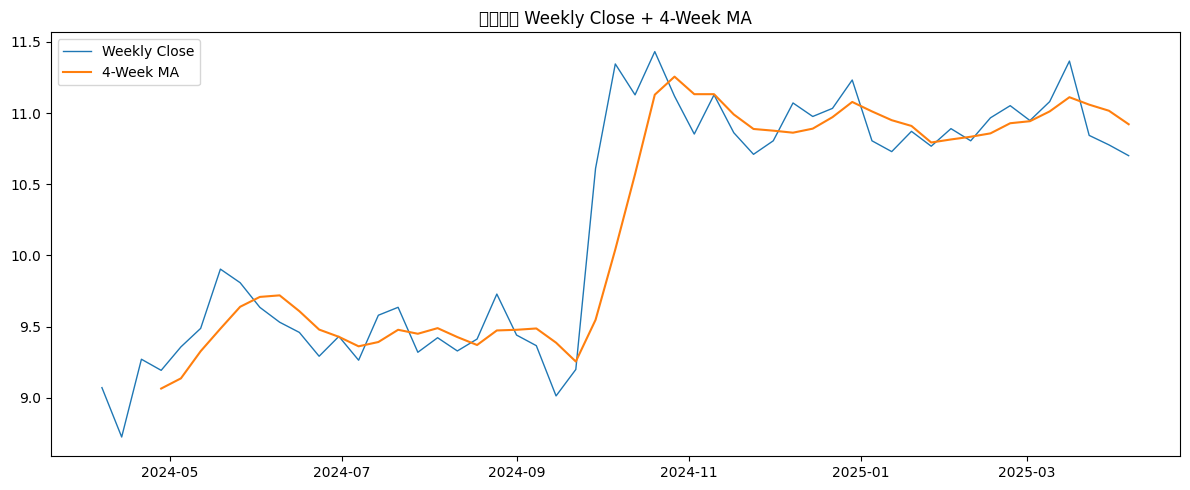

In [23]:
import matplotlib.pyplot as plt

weekly['ma_4'] = weekly['close'].rolling(4).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.index, weekly['close'], label='Weekly Close', linewidth=1)
ax.plot(weekly.index, weekly['ma_4'], label='4-Week MA', linewidth=1.5)
ax.legend()
ax.set_title('平安银行 Weekly Close + 4-Week MA')
plt.tight_layout()
plt.show()

In [24]:
last_by_iloc = df.iloc[-1]
last_date = df.index[-1]
last_by_loc = df.loc[last_date]

print("iloc[-1]:")
print(last_by_iloc)
print()
print(f"loc['{last_date.date()}']:")
print(last_by_loc)
print()
print("Match:", last_by_iloc.equals(last_by_loc))

iloc[-1]:
open      1.070094e+01
high      1.072943e+01
low       1.065347e+01
close     1.070094e+01
volume    6.814704e+07
ma_20     1.095256e+01
ma_vol    1.233217e+08
Name: 2025-04-01 00:00:00, dtype: float64

loc['2025-04-01']:
open      1.070094e+01
high      1.072943e+01
low       1.065347e+01
close     1.070094e+01
volume    6.814704e+07
ma_20     1.095256e+01
ma_vol    1.233217e+08
Name: 2025-04-01 00:00:00, dtype: float64

Match: True
